# Q6: Climate Derivatives Analysis (Temperature Data)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

lat, lon = 26.4499, 80.3319

url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date=2010-01-01&end_date=2020-12-31&daily=temperature_2m_mean&timezone=auto"

response = requests.get(url)
data = response.json()

df = pd.DataFrame({
    "Date": pd.to_datetime(data["daily"]["time"]),
    "Temp": pd.to_numeric(data["daily"]["temperature_2m_mean"], errors="coerce")
}).dropna()

df = df.sort_values("Date").set_index("Date")
df.head()

,Temp
Date,
2010-01-01,14.5
2010-01-02,14.3
2010-01-03,14.9
2010-01-04,15.4
2010-01-05,14.2


## Plot Time Series

/tmp/ipykernel_5758/37367114.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df["Temp"].resample("M").mean()


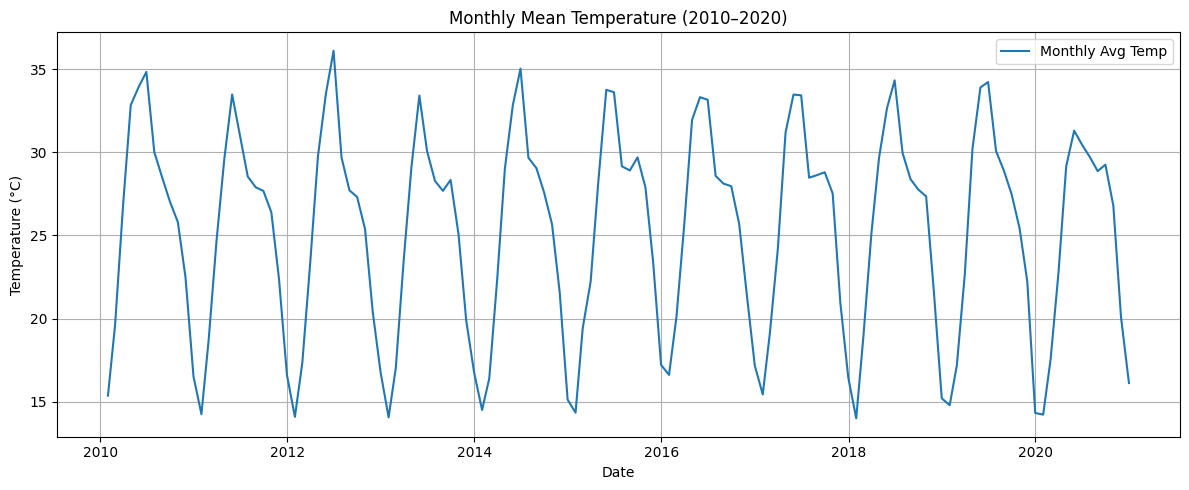

In [ ]:
monthly_temp = df["Temp"].resample("M").mean()

# Plot monthly temperature series
plt.figure(figsize=(12, 5))
plt.plot(monthly_temp.index, monthly_temp.values, label="Monthly Avg Temp")
plt.title("Monthly Mean Temperature (2010–2020)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

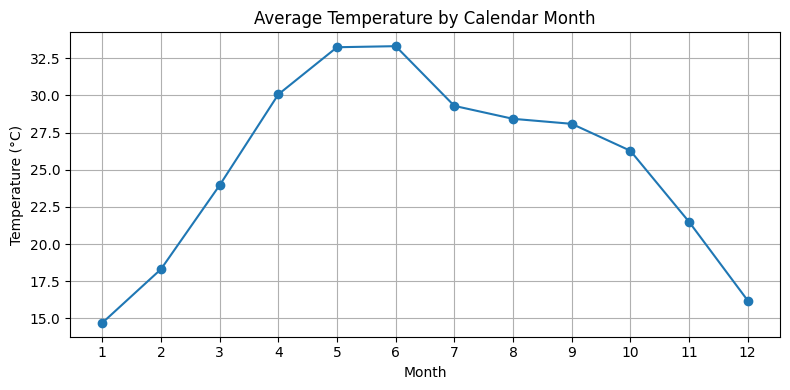

In [ ]:
month_avg = monthly_temp.groupby(monthly_temp.index.month).mean()
plt.figure(figsize=(8, 4))
plt.plot(month_avg.index, month_avg.values, marker="o")
plt.title("Average Temperature by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

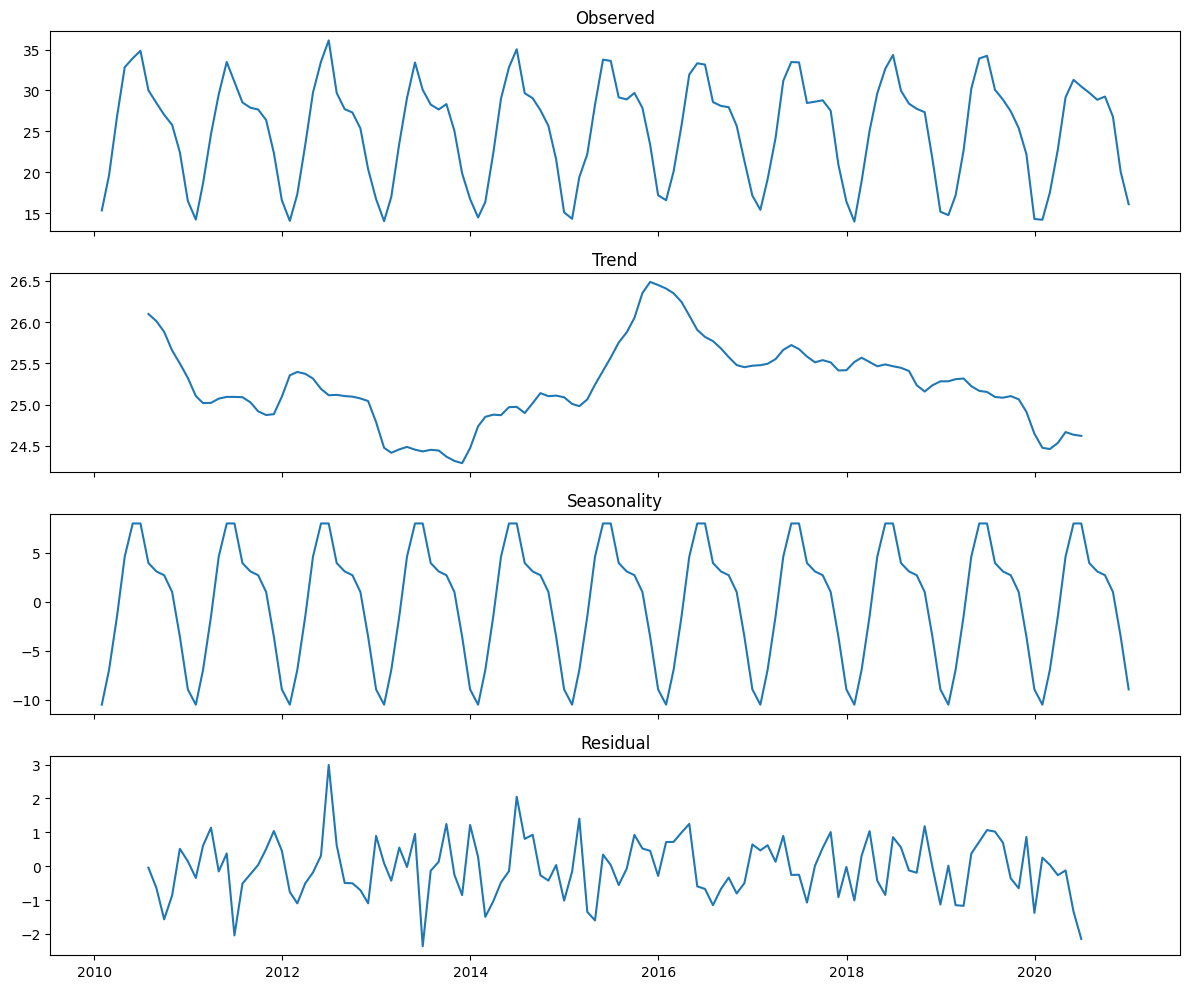

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(monthly_temp, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(decomp.observed)
axes[0].set_title("Observed")
axes[1].plot(decomp.trend)
axes[1].set_title("Trend")
axes[2].plot(decomp.seasonal)
axes[2].set_title("Seasonality")
axes[3].plot(decomp.resid)
axes[3].set_title("Residual")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5758/3628023315.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_hdd = df["HDD"].resample("M").sum()
/tmp/ipykernel_5758/3628023315.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_cdd = df["CDD"].resample("M").sum()


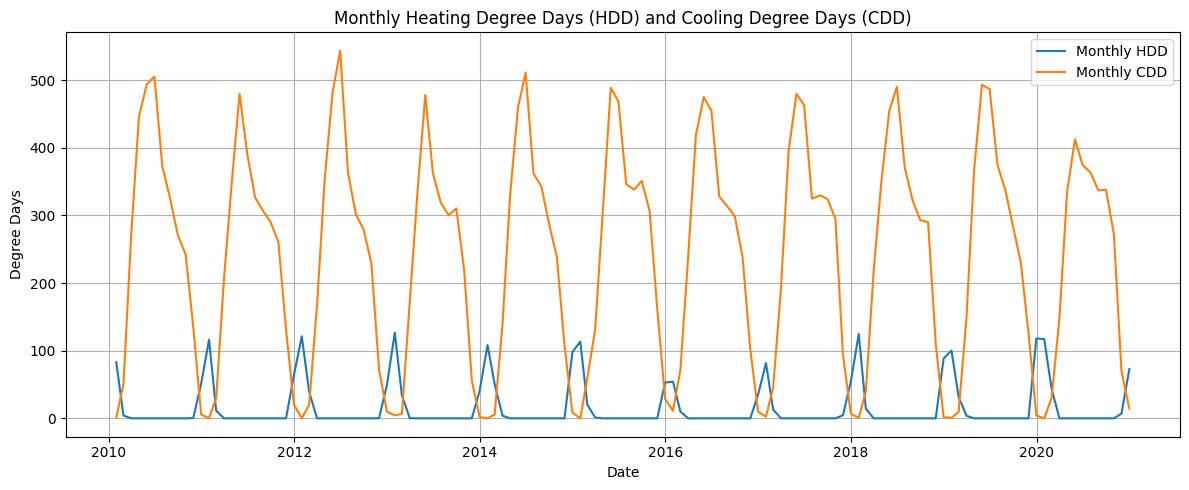

In [ ]:
base_temp = 18.0  # standard base temperature in °C

df["HDD"] = np.maximum(base_temp - df["Temp"], 0)
df["CDD"] = np.maximum(df["Temp"] - base_temp, 0)

monthly_hdd = df["HDD"].resample("M").sum()
monthly_cdd = df["CDD"].resample("M").sum()

# Plot derivative index
plt.figure(figsize=(12, 5))
plt.plot(monthly_hdd.index, monthly_hdd.values, label="Monthly HDD")
plt.plot(monthly_cdd.index, monthly_cdd.values, label="Monthly CDD")
plt.title("Monthly Heating Degree Days (HDD) and Cooling Degree Days (CDD)")
plt.xlabel("Date")
plt.ylabel("Degree Days")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# SARIMAX Forecast

In [ ]:
train = monthly_temp[:-12]
test = monthly_temp[-12:]

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               Temp   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -142.652
Date:                            Tue, 31 Mar 2026   AIC                            295.303
Time:                                    12:38:55   BIC                            307.966
Sample:                                01-31-2010   HQIC                           300.416
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3163      0.158      1.997      0.046       0.006       0.627
ma.L1         -0.8874      0.079   

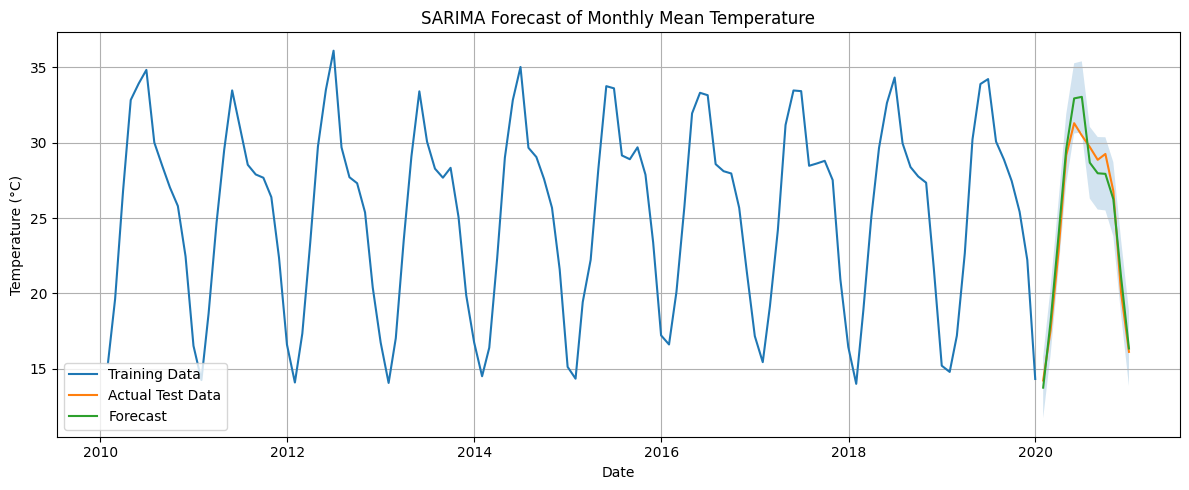

In [ ]:
forecast_test = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast_test.predicted_mean
forecast_ci = forecast_test.conf_int()

# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Training Data")
plt.plot(test.index, test.values, label="Actual Test Data")
plt.plot(forecast_mean.index, forecast_mean.values, label="Forecast")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2
)
plt.title("SARIMA Forecast of Monthly Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


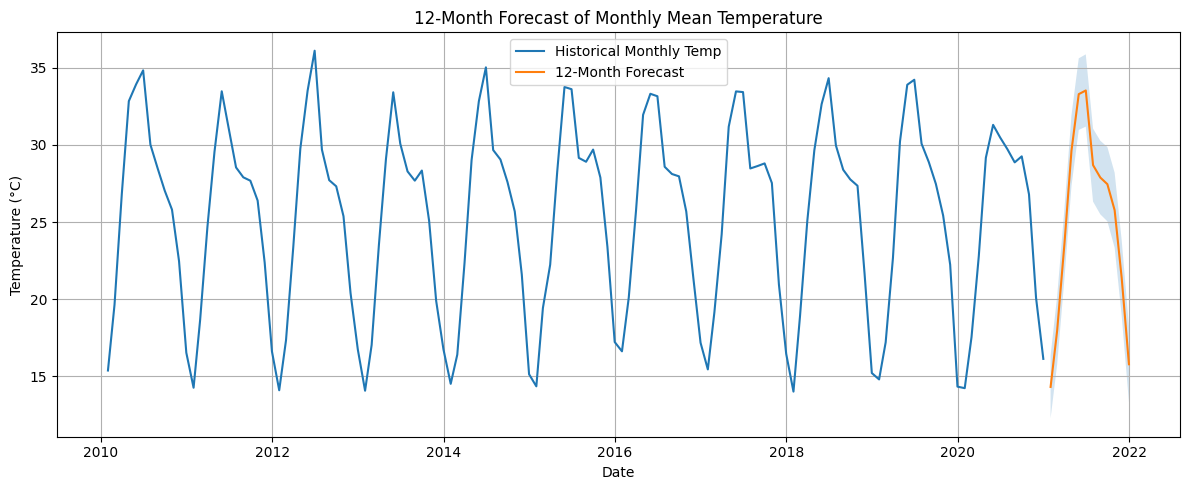

In [ ]:
final_model = SARIMAX(
    monthly_temp,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_forecast = final_model.get_forecast(steps=12)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(monthly_temp.index, monthly_temp.values, label="Historical Monthly Temp")
plt.plot(future_mean.index, future_mean.values, label="12-Month Forecast")
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2
)
plt.title("12-Month Forecast of Monthly Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Heating Degree Days (HDD)

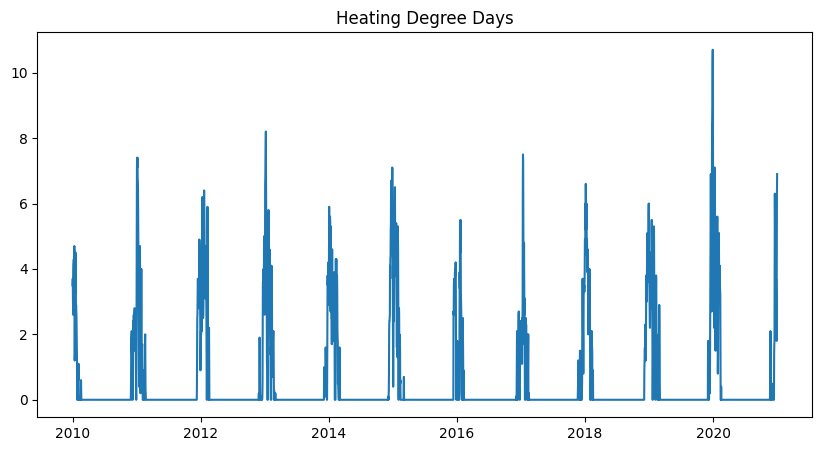

In [ ]:
base_temp = 18

df["HDD"] = (base_temp - df["Temp"]).clip(lower=0)

plt.figure(figsize=(10,5))
plt.plot(df.index, df["HDD"])
plt.title("Heating Degree Days")
plt.show()

## Derivative Payoff Simulation

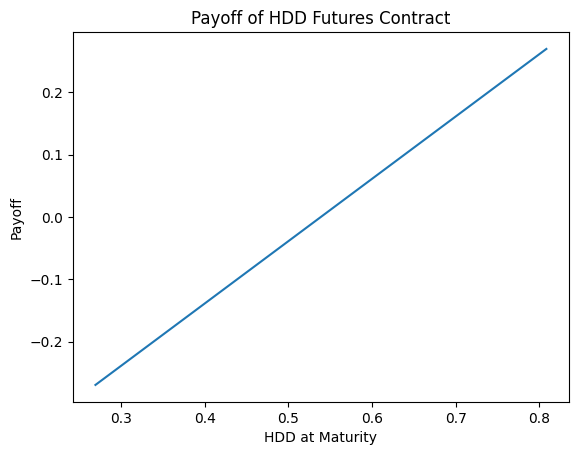

In [ ]:
import numpy as np

# Simulate HDD payoff
strike = df["HDD"].mean()
simulated = np.linspace(strike*0.5, strike*1.5, 50)

payoff = simulated - strike

plt.plot(simulated, payoff)
plt.xlabel("HDD at Maturity")
plt.ylabel("Payoff")
plt.title("Payoff of HDD Futures Contract")
plt.show()